In [1]:
import yfinance as yf
import pandas as pd
import time
from datetime import datetime

# --- 1. Definizione dell'Universo ---
def get_sp500_tickers():
    url = "https://raw.githubusercontent.com/datasets/s-and-p-500-companies/master/data/constituents.csv"
    try:
        df = pd.read_csv(url)
        # Fix per simboli Yahoo (es. BRK.B -> BRK-B)
        tickers = [t.replace('.', '-') for t in df['Symbol'].tolist()]
        return tickers
    except Exception as e:
        print(f"Errore download ticker: {e}")
        return []

# --- 2. Estrazione Dati ---
def get_fcf_data(ticker_symbol):
    stock = yf.Ticker(ticker_symbol)
    
    try:
        # --- A. Market Cap (Essenziale) ---
        # Usiamo l'attributo diretto, più sicuro del .get() su fast_info
        try:
            market_cap = stock.fast_info.market_cap
        except:
            market_cap = stock.info.get('marketCap')

        if not market_cap: return None

        # --- B. Prezzo (Per visualizzazione) ---
        try:
            # Tenta prima fast_info, poi regularMarketPrice
            price = stock.fast_info.last_price
            if price is None:
                price = stock.info.get('currentPrice')
        except:
            price = 0 # Non blocchiamo se manca solo il prezzo visuale

        # --- C. Cash Flow (Contabilità) ---
        cashflow = stock.cashflow
        if cashflow.empty: return None

        # Funzione helper per le etichette variabili
        def get_item(df, keys):
            for k in keys:
                if k in df.index:
                    return df.loc[k].iloc[0] # Anno più recente
            return None

        # 1. OCF
        ocf = get_item(cashflow, ['Total Cash From Operating Activities', 'Operating Cash Flow'])
        # 2. CapEx
        capex = get_item(cashflow, ['Capital Expenditures', 'Capital Expenditure'])
        # 3. Dividendi
        dividends = get_item(cashflow, ['Cash Dividends Paid', 'Common Stock Dividend Paid'])
        if dividends is None: dividends = 0

        if ocf is None or capex is None: return None

        # --- D. Calcolo Strategia ---
        # CapEx e Dividendi sono negativi nel DF -> Si sommano algebricamente
        fcf = ocf + capex
        net_fcf = fcf + dividends
        
        # Calcolo Yields
        fcf_yield = (fcf / market_cap) * 100
        net_fcf_yield = (net_fcf / market_cap) * 100

        return {
            'Ticker': ticker_symbol,
            'Price ($)': round(price, 2) if price else 0,
            'Mkt Cap (B)': round(market_cap / 1_000_000_000, 2),
            'FCF Yield (%)': round(fcf_yield, 2),
            'Net FCF Yield (%)': round(net_fcf_yield, 2), # <--- IL KEY RATIO
            'Sector': stock.info.get('sector', 'N/A')
        }

    except Exception:
        return None

# --- 3. Main Loop ---
def main():
    print("--- PORTFOLIO123 STRATEGY SCANNER ---")
    tickers = get_sp500_tickers()
    
    # ---------------------------------------------------------
    # IMPOSTAZIONE: Se vuoi fare un test veloce, lascia [:50]
    # Se vuoi TUTTO, togli le parentesi quadre e metti: tickers
    tickers_to_scan = tickers  
    # ---------------------------------------------------------

    print(f"Inizio scansione di {len(tickers_to_scan)} titoli...")
    print("Nota: Ignoreremo errori '404' o dati mancanti di Yahoo.")

    results = []
    start_time = time.time()

    for i, ticker in enumerate(tickers_to_scan):
        # Stampa progresso (es. 15/500)
        print(f"[{i+1}/{len(tickers_to_scan)}] Analisi: {ticker:<5}", end='\r')
        
        data = get_fcf_data(ticker)
        if data:
            results.append(data)

    elapsed = time.time() - start_time
    print(f"\n\nScansione completata in {elapsed:.1f} secondi.")
    print(f"Titoli validi trovati: {len(results)}")

    if results:
        df = pd.DataFrame(results)
        
        # Ordina per il Net FCF Yield (Strategia Portfolio123)
        df = df.sort_values(by='Net FCF Yield (%)', ascending=False)
        
        # Reset indice
        df.reset_index(drop=True, inplace=True)

        # Salva in Excel
        filename = f"Strategy_FCF_{datetime.now().strftime('%Y%m%d')}.xlsx"
        df.to_excel(filename, index=False)
        print(f"\nFILE SALVATO: {filename}")
        
        # Anteprima Console Top 10
        print("\n--- TOP 10 OPPORTUNITÀ (NET FCF YIELD) ---")
        print(df.head(10).to_string(index=False))
    else:
        print("Nessun dato raccolto.")

if __name__ == "__main__":
    main()

--- PORTFOLIO123 STRATEGY SCANNER ---
Inizio scansione di 503 titoli...
Nota: Ignoreremo errori '404' o dati mancanti di Yahoo.


$FI: possibly delisted; no price data found  (period=5d)


HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: WBA"}}}
$WBA: possibly delisted; no price data found  (period=1y) (Yahoo error = "No data found, symbol may be delisted")
$WBA: possibly delisted; no price data found  (period=5d) (Yahoo error = "No data found, symbol may be delisted")


[503/503] Analisi: ZTS  

Scansione completata in 645.5 secondi.
Titoli validi trovati: 481

FILE SALVATO: Strategy_FCF_20251124.xlsx

--- TOP 10 OPPORTUNITÀ (NET FCF YIELD) ---
Ticker  Price ($)  Mkt Cap (B)  FCF Yield (%)  Net FCF Yield (%)             Sector
   PFG      84.41        18.80          24.11              20.61 Financial Services
   DVA     120.36         8.61          17.04              17.04         Healthcare
    FI      60.84        32.72          15.47              15.47         Technology
   GPN      72.97        17.70          16.14              14.71        Industrials
   AMP     446.39        42.08          15.25              13.89 Financial Services
  ENPH      26.62         3.48          13.78              13.78         Technology
  ACGL      91.83        34.27          19.32              13.76 Financial Services
   MGM      32.44         8.87          13.66              13.66  Consumer Cyclical
   ALL     214.35        56.48          15.44              13.53 F

In [1]:
import pandas as pd
import time
import yfinance as yf
from io import StringIO
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.chrome.options import Options

# --- 1. SPIDERS: Recupero Universo (Selenium) ---
def get_sp500_tickers_selenium():
    print("--- FASE 1: Recupero Lista S&P 500 (Selenium) ---")
    chrome_options = Options()
    chrome_options.add_argument("--headless") 
    chrome_options.add_argument("--no-sandbox")
    chrome_options.add_argument("--disable-dev-shm-usage")
    
    driver = None
    try:
        service = Service(ChromeDriverManager().install())
        driver = webdriver.Chrome(service=service, options=chrome_options)
        
        url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
        driver.get(url)
        time.sleep(3)
        
        # Parsing intelligente della tabella
        tables = pd.read_html(StringIO(driver.page_source))
        sp500_df = None
        
        for table in tables:
            if 'Symbol' in table.columns and len(table) > 400:
                sp500_df = table
                break
        
        if sp500_df is None: raise ValueError("Tabella S&P 500 non trovata.")
            
        tickers = [t.replace('.', '-') for t in sp500_df['Symbol'].tolist()]
        print(f"Trovati {len(tickers)} ticker.")
        return tickers
        
    except Exception as e:
        print(f"Errore Selenium: {e}")
        return []
    finally:
        if driver: driver.quit()

# --- 2. FILTRO: Top N per Capitalizzazione ---
def filter_top_market_cap(tickers, top_n=120):
    print(f"\n--- FASE 2: Filtraggio Top {top_n} per Market Cap ---")
    data = []
    
    # Batch processing simulato per feedback visivo
    total = len(tickers)
    for i, t in enumerate(tickers):
        print(f"[{i+1}/{total}] Check Cap: {t:<5}", end="\r")
        try:
            # fast_info è rapidissimo e non scarica tutto il bilancio
            stock = yf.Ticker(t)
            cap = stock.fast_info.market_cap
            if cap:
                data.append((t, cap))
        except:
            pass
            
    # Creazione DataFrame e Ordinamento
    df_cap = pd.DataFrame(data, columns=['Ticker', 'MarketCap'])
    df_cap = df_cap.sort_values(by='MarketCap', ascending=False).head(top_n)
    
    top_tickers = df_cap['Ticker'].tolist()
    cutoff_stock = df_cap.iloc[-1]
    print(f"\n\nSelezionati Top {top_n}.")
    print(f"La più piccola è {cutoff_stock['Ticker']} con {cutoff_stock['MarketCap']/1e9:.2f}B $")
    return top_tickers

# --- 3. ANALISI: Calcolo Net FCF Yield ---
def analyze_fundamentals(tickers):
    print(f"\n--- FASE 3: Analisi Fondamentale + TREND FILTER ({len(tickers)} titoli) ---")
    results = []
    
    for i, t in enumerate(tickers):
        print(f"[{i+1}/{len(tickers)}] Analisi: {t:<5}", end="\r")
        
        try:
            stock = yf.Ticker(t)
            
            # 1. Recupero Prezzi per il Trend (Ultimo anno)
            hist = stock.history(period="1y")
            if hist.empty: continue
            
            current_price = hist['Close'].iloc[-1]
            sma_200 = hist['Close'].mean() # Media semplice dell'ultimo anno (~200gg trading)
            
            # --- FILTRO MOMENTUM: Evitiamo i coltelli che cadono ---
            # Se il prezzo è sotto la media dell'ultimo anno del 10%, scartiamo.
            # (Un titolo economico che sta crollando è spesso una trappola)
            trend_ratio = current_price / sma_200
            
            # Se il prezzo è < 90% della media annuale, è un trend bruttissimo. SKIP.
            if trend_ratio < 0.90: 
                # print(f"Scartato {t}: Trend ribassista (Prezzo {current_price:.2f} < SMA {sma_200:.2f})")
                continue

            # 2. Dati Fondamentali (Come prima)
            mkt_cap = stock.fast_info.market_cap
            if not mkt_cap: continue
            
            cf = stock.cashflow
            if cf.empty: continue
            
            def get_val(df, keys):
                for k in keys:
                    if k in df.index: return df.loc[k].iloc[0]
                return None

            ocf = get_val(cf, ['Total Cash From Operating Activities', 'Operating Cash Flow'])
            capex = get_val(cf, ['Capital Expenditures', 'Capital Expenditure'])
            dividends = get_val(cf, ['Cash Dividends Paid', 'Common Stock Dividend Paid'])
            if dividends is None: dividends = 0

            if ocf is None or capex is None: continue

            fcf = ocf + capex
            net_fcf = fcf + dividends
            
            yield_pct = (net_fcf / mkt_cap) * 100
            
            # Escludiamo anomalie eccessive (>30% spesso è un errore dati o fallimento imminente)
            if yield_pct > 30: continue

            results.append({
                'Ticker': t,
                'Price': current_price,
                'Trend (Px/SMA200)': round(trend_ratio, 2), # > 1.0 è Bullish
                'Market Cap (B)': round(mkt_cap / 1e9, 2),
                'Net FCF Yield (%)': round(yield_pct, 2),
                'Sector': stock.info.get('sector', 'N/A')
            })
            
        except Exception:
            continue
            
    return pd.DataFrame(results)
# --- MAIN ---
if __name__ == "__main__":
    # 1. Ottieni lista completa
    all_tickers = get_sp500_tickers_selenium()
    
    if all_tickers:
        # 2. Filtra solo le Top 120 (Big Caps)
        top_tickers = filter_top_market_cap(all_tickers, top_n=120)
        
        # 3. Analizza i flussi di cassa
        df_results = analyze_fundamentals(top_tickers)
        
        if not df_results.empty:
            # 4. Ordina e Salva
            df_sorted = df_results.sort_values(by='Net FCF Yield (%)', ascending=False)
            
            print("\n\n--- TOP 15 VALUE STOCKS (Top 120 Universe) ---")
            pd.options.display.float_format = '{:.2f}'.format
            print(df_sorted[['Ticker', 'Price', 'Market Cap (B)', 'Net FCF Yield (%)', 'Sector']].head(15))
            
            filename = "Portfolio123_Strategy_Top120.xlsx"
            df_sorted.to_excel(filename, index=False)
            print(f"\nReport completo salvato in: {filename}")
        else:
            print("Nessun dato valido estratto.")

--- FASE 1: Recupero Lista S&P 500 (Selenium) ---
Trovati 503 ticker.

--- FASE 2: Filtraggio Top 120 per Market Cap ---
[503/503] Check Cap: ZTS  

Selezionati Top 120.
La più piccola è MMM con 89.88B $

--- FASE 3: Analisi Fondamentale + TREND FILTER (120 titoli) ---
[120/120] Analisi: MMM  

--- TOP 15 VALUE STOCKS (Top 120 Universe) ---
   Ticker   Price  Market Cap (B)  Net FCF Yield (%)                  Sector
72    COF  209.28          133.84              11.80      Financial Services
94    BMY   47.88           97.48               9.31              Healthcare
88   IBKR   62.34          105.97               8.10      Financial Services
47      T   25.70          182.23               5.65  Communication Services
50   QCOM  165.84          178.94               5.04              Technology
86    MCK  868.67          108.05               4.52              Healthcare
55     VZ   40.25          169.73               4.52  Communication Services
46    DIS  102.25          183.84        

--- GENERAZIONE GRAFICO PERFORMANCE ---
Portafoglio Strategia: ['COF', 'BMY', 'IBKR', 'T', 'QCOM', 'MCK', 'VZ', 'DIS', 'BKNG', 'HCA', 'AXP', 'GILD', 'MRK', 'LOW', 'COP']
Scaricamento dati storici prezzi...

--- RISULTATI (1y) ---
Rendimento Strategia (Top 15): 11.09%
Rendimento S&P 500 (SPY):      13.32%
ALPHA (Sovraperformance):      -2.23%


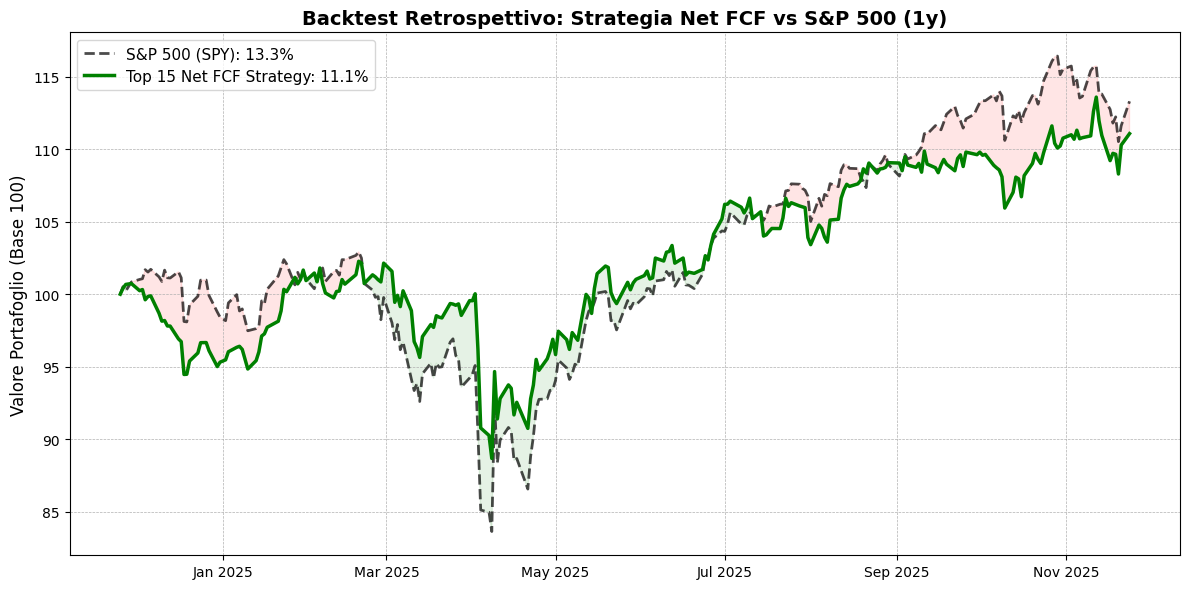

In [2]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# --- CONFIGURAZIONE ---
FILENAME = "Portfolio123_Strategy_Top120.xlsx"
BENCHMARK = "SPY"  # L'ETF dello S&P 500
PERIOD = "1y"      # '1y' = ultimo anno, 'ytd' = da inizio anno

def plot_performance():
    print("--- GENERAZIONE GRAFICO PERFORMANCE ---")
    
    # 1. Carica il Portafoglio generato
    try:
        df = pd.read_excel(FILENAME)
        # Prendiamo le Top 15 azioni della strategia
        top_stocks = df.head(15)['Ticker'].tolist()
        print(f"Portafoglio Strategia: {top_stocks}")
    except FileNotFoundError:
        print(f"Errore: File {FILENAME} non trovato. Esegui prima lo script precedente.")
        return

    # 2. Scarica i dati storici (Prezzi di Chiusura)
    print("Scaricamento dati storici prezzi...")
    tickers_to_download = top_stocks + [BENCHMARK]
    
    # yfinance scarica tutto insieme
    data = yf.download(tickers_to_download, period=PERIOD, auto_adjust=True, progress=False)['Close']
    
    if data.empty:
        print("Errore nel download dei prezzi.")
        return

    # 3. Calcola i Rendimenti
    # Rimuoviamo righe vuote se ci sono
    data.dropna(inplace=True)
    
    # Normalizzazione: Facciamo partire tutto da 100 (Base 100)
    # Formula: (Prezzo Giorno X / Prezzo Giorno 0) * 100
    normalized_data = (data / data.iloc[0]) * 100
    
    # 4. Costruisci l'indice del Portafoglio (Equal Weight)
    # Assumiamo di aver investito la stessa cifra in ognuna delle 15 azioni
    # La performance del portafoglio è la media delle performance delle singole azioni
    strategy_curve = normalized_data[top_stocks].mean(axis=1)
    benchmark_curve = normalized_data[BENCHMARK]
    
    # Calcolo Rendimento Totale Finale
    strat_return = strategy_curve.iloc[-1] - 100
    bench_return = benchmark_curve.iloc[-1] - 100
    alpha = strat_return - bench_return

    print(f"\n--- RISULTATI ({PERIOD}) ---")
    print(f"Rendimento Strategia (Top 15): {strat_return:.2f}%")
    print(f"Rendimento S&P 500 (SPY):      {bench_return:.2f}%")
    print(f"ALPHA (Sovraperformance):      {alpha:+.2f}%")

    # 5. PLOTTING (Grafico Professionale)
    plt.figure(figsize=(12, 6))
    
    # Plot Benchmark (Area grigia o linea nera)
    plt.plot(benchmark_curve.index, benchmark_curve, label=f'S&P 500 (SPY): {bench_return:.1f}%', 
             color='black', linewidth=2, alpha=0.7, linestyle='--')
    
    # Plot Strategia (Linea Verde Spessa)
    plt.plot(strategy_curve.index, strategy_curve, label=f'Top 15 Net FCF Strategy: {strat_return:.1f}%', 
             color='#008000', linewidth=2.5)
    
    # Fill between per evidenziare il guadagno/perdita
    plt.fill_between(strategy_curve.index, strategy_curve, benchmark_curve, 
                     where=(strategy_curve >= benchmark_curve), color='green', alpha=0.1, interpolate=True)
    plt.fill_between(strategy_curve.index, strategy_curve, benchmark_curve, 
                     where=(strategy_curve < benchmark_curve), color='red', alpha=0.1, interpolate=True)

    # Formattazione
    plt.title(f'Backtest Retrospettivo: Strategia Net FCF vs S&P 500 ({PERIOD})', fontsize=14, fontweight='bold')
    plt.ylabel('Valore Portafoglio (Base 100)', fontsize=12)
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.legend(loc='best', fontsize=11)
    
    # Formatta asse X per date leggibili
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    plot_performance()

In [3]:
import pandas as pd
import time
import yfinance as yf
from io import StringIO
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.chrome.options import Options
from datetime import datetime

# --- CONFIGURAZIONE UTENTE ---
TOP_N_CAP = 120              # Analizza solo le prime N per grandezza
MIN_TREND_RATIO = 0.95       # Prezzo deve essere almeno il 95% della media a 200gg (1.0 = sopra media)
EXCLUDE_FINANCIALS = True    # Metti False se vuoi includere Banche/Assicurazioni

# --- 1. SPIDERS: Recupero Universo (Selenium) ---
def get_sp500_tickers_selenium():
    print("--- FASE 1: Recupero Lista S&P 500 (Selenium) ---")
    chrome_options = Options()
    chrome_options.add_argument("--headless") 
    chrome_options.add_argument("--no-sandbox")
    chrome_options.add_argument("--disable-dev-shm-usage")
    
    driver = None
    try:
        service = Service(ChromeDriverManager().install())
        driver = webdriver.Chrome(service=service, options=chrome_options)
        driver.get("https://en.wikipedia.org/wiki/List_of_S%26P_500_companies")
        time.sleep(3)
        
        tables = pd.read_html(StringIO(driver.page_source))
        sp500_df = None
        for table in tables:
            if 'Symbol' in table.columns and len(table) > 400:
                sp500_df = table
                break
        
        if sp500_df is None: raise ValueError("Tabella non trovata.")
        tickers = [t.replace('.', '-') for t in sp500_df['Symbol'].tolist()]
        print(f"Trovati {len(tickers)} ticker.")
        return tickers
    except Exception as e:
        print(f"Errore Selenium: {e}")
        return []
    finally:
        if driver: driver.quit()

# --- 2. FILTRO CAP ---
def filter_top_market_cap(tickers, top_n=150):
    print(f"\n--- FASE 2: Filtraggio Top {top_n} Market Cap ---")
    data = []
    for i, t in enumerate(tickers):
        print(f"[{i+1}/{len(tickers)}] Check Cap: {t:<5}", end="\r")
        try:
            stock = yf.Ticker(t)
            cap = stock.fast_info.market_cap
            if cap: data.append((t, cap))
        except: pass
    
    df = pd.DataFrame(data, columns=['Ticker', 'MarketCap'])
    df = df.sort_values(by='MarketCap', ascending=False).head(top_n)
    return df['Ticker'].tolist()

# --- 3. ANALISI CORE ---
def analyze_stock(ticker):
    try:
        stock = yf.Ticker(ticker)
        
        # A. SETTORE (Filtro rapido)
        sector = stock.info.get('sector', 'Unknown')
        if EXCLUDE_FINANCIALS and sector in ['Financial Services', 'Utilities']:
            return None

        # B. TREND (SMA 200)
        hist = stock.history(period="1y")
        if hist.empty: return None
        
        current_price = hist['Close'].iloc[-1]
        sma_200 = hist['Close'].mean()
        trend_ratio = current_price / sma_200
        
        # Filtro Rigido: Se il trend è rotto, scarta.
        if trend_ratio < MIN_TREND_RATIO:
            return None

        # C. DATI FONDAMENTALI
        mkt_cap = stock.fast_info.market_cap
        if not mkt_cap: return None
        
        cf = stock.cashflow
        if cf.empty: return None
        
        # Helper estrazione
        def get_val(df, keys):
            for k in keys:
                if k in df.index: return df.loc[k].iloc[0]
            return None

        ocf = get_val(cf, ['Total Cash From Operating Activities', 'Operating Cash Flow'])
        capex = get_val(cf, ['Capital Expenditures', 'Capital Expenditure']) # Negativo
        dividends = get_val(cf, ['Cash Dividends Paid', 'Common Stock Dividend Paid']) # Negativo
        if dividends is None: dividends = 0

        if ocf is None or capex is None: return None

        # Calcolo Net FCF
        fcf = ocf + capex
        net_fcf = fcf + dividends
        
        yield_pct = (net_fcf / mkt_cap) * 100
        
        # Sanity check (>50% yield è quasi sempre un errore dati o azienda fallita)
        if yield_pct > 50 or yield_pct < -50: return None

        return {
            'Ticker': ticker,
            'Price': round(current_price, 2),
            'Trend Score': round(trend_ratio, 2), # > 1.0 = Bullish
            'Mkt Cap (B)': round(mkt_cap / 1e9, 2),
            'Net FCF Yield (%)': round(yield_pct, 2),
            'Sector': sector
        }

    except Exception:
        return None

# --- MAIN ---
def main():
    start_time = time.time()
    
    # 1. Lista
    tickers = get_sp500_tickers_selenium()
    if not tickers: return

    # 2. Cap Filter
    candidates = filter_top_market_cap(tickers, top_n=TOP_N_CAP)

    # 3. Deep Analysis
    print(f"\n\n--- FASE 3: Deep Scan & Trend Filter ({len(candidates)} titoli) ---")
    results = []
    for i, t in enumerate(candidates):
        print(f"[{i+1}/{len(candidates)}] Scanning: {t:<5}", end="\r")
        data = analyze_stock(t)
        if data:
            results.append(data)

    # 4. Report
    if results:
        df = pd.DataFrame(results)
        df = df.sort_values(by='Net FCF Yield (%)', ascending=False)
        
        # Nome file dinamico
        filename = f"FCF_Screener_{datetime.now().strftime('%Y-%m-%d')}.xlsx"
        df.to_excel(filename, index=False)
        
        print(f"\n\n✅ ANALISI COMPLETATA in {time.time() - start_time:.1f}s")
        print(f"File salvato: {filename}")
        print("\n--- TOP 10 VALUE & MOMENTUM ---")
        pd.options.display.float_format = '{:.2f}'.format
        print(df[['Ticker', 'Price', 'Trend Score', 'Net FCF Yield (%)', 'Sector']].head(10))
    else:
        print("\nNessun risultato trovato.")

if __name__ == "__main__":
    main()

--- FASE 1: Recupero Lista S&P 500 (Selenium) ---
Trovati 503 ticker.

--- FASE 2: Filtraggio Top 120 Market Cap ---
[503/503] Check Cap: ZTS  

--- FASE 3: Deep Scan & Trend Filter (120 titoli) ---
[120/120] Scanning: MMM  

✅ ANALISI COMPLETATA in 346.8s
File salvato: FCF_Screener_2025-11-24.xlsx

--- TOP 10 VALUE & MOMENTUM ---
   Ticker   Price  Trend Score  Net FCF Yield (%)                  Sector
69    BMY   47.94         0.96               9.30              Healthcare
35      T   25.72         0.99               5.65  Communication Services
38   QCOM  166.05         1.06               5.03              Technology
41     VZ   40.28         0.98               4.52  Communication Services
65    MCK  870.08         1.26               4.51              Healthcare
45   BKNG 4897.54         0.95               4.23       Consumer Cyclical
61    HCA  504.63         1.38               4.19              Healthcare
47   GILD  125.68         1.17               4.10              Healthcare
2

In [4]:
import pandas as pd
import time
import yfinance as yf
from io import StringIO
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.chrome.options import Options

# --- CONFIGURAZIONE STRATEGIA ---
TOP_CAP_UNIVERSE = 150       # Analizziamo le 150 più grandi (Universo di qualità)
STOCKS_PER_SECTOR = 2        # Quante azioni comprare per ogni settore (Diversificazione)
MIN_TREND_SCORE = 0.95       # Filtro Trend (Prezzo > 95% della SMA 200)

# --- 1. SPIDERS: Selenium (Invariato) ---
def get_sp500_tickers_selenium():
    print("--- FASE 1: Recupero Lista S&P 500 (Selenium) ---")
    chrome_options = Options()
    chrome_options.add_argument("--headless") 
    chrome_options.add_argument("--no-sandbox")
    chrome_options.add_argument("--disable-dev-shm-usage")
    
    driver = None
    try:
        service = Service(ChromeDriverManager().install())
        driver = webdriver.Chrome(service=service, options=chrome_options)
        driver.get("https://en.wikipedia.org/wiki/List_of_S%26P_500_companies")
        time.sleep(3)
        
        tables = pd.read_html(StringIO(driver.page_source))
        sp500_df = None
        for table in tables:
            if 'Symbol' in table.columns and len(table) > 400:
                sp500_df = table
                break
        
        if sp500_df is None: raise ValueError("Tabella non trovata.")
        tickers = [t.replace('.', '-') for t in sp500_df['Symbol'].tolist()]
        print(f"Trovati {len(tickers)} ticker.")
        return tickers
    except Exception as e:
        print(f"Errore Selenium: {e}")
        return []
    finally:
        if driver: driver.quit()

# --- 2. FILTRO CAP (Invariato) ---
def filter_top_market_cap(tickers, top_n=150):
    print(f"\n--- FASE 2: Filtraggio Top {top_n} Market Cap ---")
    data = []
    for i, t in enumerate(tickers):
        print(f"[{i+1}/{len(tickers)}] Check Cap: {t:<5}", end="\r")
        try:
            stock = yf.Ticker(t)
            cap = stock.fast_info.market_cap
            if cap: data.append((t, cap))
        except: pass
    
    df = pd.DataFrame(data, columns=['Ticker', 'MarketCap'])
    df = df.sort_values(by='MarketCap', ascending=False).head(top_n)
    return df['Ticker'].tolist()

# --- 3. ANALISI FCF (Senza esclusioni di settore) ---
def analyze_stock(ticker):
    try:
        stock = yf.Ticker(ticker)
        
        # A. TREND FILTER (Cruciale per evitare trappole)
        hist = stock.history(period="1y")
        if hist.empty: return None
        
        current_price = hist['Close'].iloc[-1]
        sma_200 = hist['Close'].mean()
        trend_ratio = current_price / sma_200
        
        if trend_ratio < MIN_TREND_SCORE: return None # Trend ribassista

        # B. SETTORE (Lo salviamo per il raggruppamento dopo)
        sector = stock.info.get('sector', 'Unknown')
        if sector == 'Unknown': return None

        # C. DATI CASH FLOW
        mkt_cap = stock.fast_info.market_cap
        if not mkt_cap: return None
        
        cf = stock.cashflow
        if cf.empty: return None
        
        def get_val(df, keys):
            for k in keys:
                if k in df.index: return df.loc[k].iloc[0]
            return None

        ocf = get_val(cf, ['Total Cash From Operating Activities', 'Operating Cash Flow'])
        capex = get_val(cf, ['Capital Expenditures', 'Capital Expenditure'])
        dividends = get_val(cf, ['Cash Dividends Paid', 'Common Stock Dividend Paid'])
        if dividends is None: dividends = 0
        if ocf is None or capex is None: return None

        # FCF Calculation
        fcf = ocf + capex
        net_fcf = fcf + dividends
        yield_pct = (net_fcf / mkt_cap) * 100
        
        if yield_pct > 60 or yield_pct < -60: return None # Sanity Check

        return {
            'Ticker': ticker,
            'Price': round(current_price, 2),
            'Sector': sector, # Chiave di raggruppamento
            'Net FCF Yield (%)': round(yield_pct, 2),
            'Trend Score': round(trend_ratio, 2)
        }

    except Exception:
        return None

# --- MAIN: LOGICA "BEST OF BREED" ---
def main():
    start_time = time.time()
    tickers = get_sp500_tickers_selenium()
    candidates = filter_top_market_cap(tickers, top_n=TOP_CAP_UNIVERSE)

    print(f"\n\n--- FASE 3: Analisi Approfondita ({len(candidates)} titoli) ---")
    results = []
    for i, t in enumerate(candidates):
        print(f"[{i+1}/{len(candidates)}] Scanning: {t:<5}", end="\r")
        data = analyze_stock(t)
        if data: results.append(data)

    if results:
        df = pd.DataFrame(results)
        
        # --- FASE 4: SELEZIONE PER SETTORE ---
        print(f"\n\n--- FASE 4: Selezione 'Best of Breed' (Top {STOCKS_PER_SECTOR} per Settore) ---")
        
        final_portfolio = pd.DataFrame()
        sectors = df['Sector'].unique()
        
        for sector in sorted(sectors):
            # Filtra per settore
            sector_df = df[df['Sector'] == sector]
            
            # Ordina per Yield (i migliori in alto)
            sector_df = sector_df.sort_values(by='Net FCF Yield (%)', ascending=False)
            
            # Prendi i Top N
            top_picks = sector_df.head(STOCKS_PER_SECTOR)
            
            if not top_picks.empty:
                final_portfolio = pd.concat([final_portfolio, top_picks])
                
                # Print carino per la console
                picks_str = ", ".join([f"{row['Ticker']} ({row['Net FCF Yield (%)']}%)" for _, row in top_picks.iterrows()])
                print(f"✅ {sector:<25} -> {picks_str}")

        # Export Excel
        filename = f"Strategy_SectorNeutral_{datetime.now().strftime('%Y-%m-%d')}.xlsx"
        final_portfolio.to_excel(filename, index=False)
        print(f"\nFILE SALVATO: {filename}")
        
    else:
        print("\nNessun risultato trovato.")

if __name__ == "__main__":
    main()

--- FASE 1: Recupero Lista S&P 500 (Selenium) ---
Trovati 503 ticker.

--- FASE 2: Filtraggio Top 150 Market Cap ---
[503/503] Check Cap: ZTS  

--- FASE 3: Analisi Approfondita (150 titoli) ---
[150/150] Scanning: MDLZ 

--- FASE 4: Selezione 'Best of Breed' (Top 2 per Settore) ---
✅ Basic Materials           -> NEM (1.9%), SHW (1.62%)
✅ Communication Services    -> T (5.66%), VZ (4.52%)
✅ Consumer Cyclical         -> BKNG (4.24%), LOW (3.98%)
✅ Consumer Defensive        -> MO (1.84%), PM (1.1%)
✅ Energy                    -> COP (3.97%), XOM (2.84%)
✅ Financial Services        -> COF (11.8%), IBKR (8.09%)
✅ Healthcare                -> BMY (9.32%), MCK (4.51%)
✅ Industrials               -> CAT (2.33%), PH (2.31%)
✅ Real Estate               -> WELL (0.47%)
✅ Technology                -> QCOM (5.03%), UBER (3.95%)
✅ Utilities                 -> NEE (0.29%), SO (-2.16%)

FILE SALVATO: Strategy_SectorNeutral_2025-11-24.xlsx


Strategy_SectorNeutral_2025-11-24.xlsx

--- GENERAZIONE GRAFICO PERFORMANCE ---
Portafoglio Strategia: ['NEM', 'SHW', 'T', 'VZ', 'BKNG', 'LOW', 'MO', 'PM', 'COP', 'XOM', 'COF', 'IBKR', 'BMY', 'MCK', 'CAT']
Scaricamento dati storici prezzi...

--- RISULTATI (4y) ---
Rendimento Strategia (Top 15): 90.83%
Rendimento S&P 500 (SPY):      50.77%
ALPHA (Sovraperformance):      +40.06%


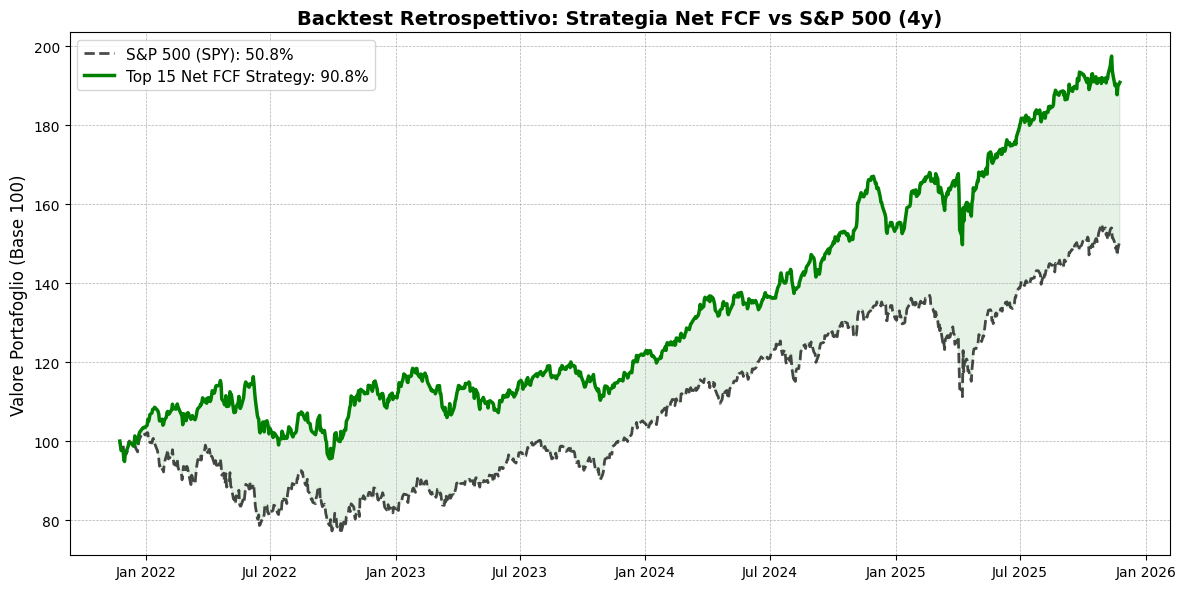

In [5]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# --- CONFIGURAZIONE ---
FILENAME = "Strategy_SectorNeutral_2025-11-24.xlsx"
BENCHMARK = "SPY"  # L'ETF dello S&P 500
PERIOD = "4y"      # '1y' = ultimo anno, 'ytd' = da inizio anno

def plot_performance():
    print("--- GENERAZIONE GRAFICO PERFORMANCE ---")
    
    # 1. Carica il Portafoglio generato
    try:
        df = pd.read_excel(FILENAME)
        # Prendiamo le Top 15 azioni della strategia
        top_stocks = df.head(15)['Ticker'].tolist()
        print(f"Portafoglio Strategia: {top_stocks}")
    except FileNotFoundError:
        print(f"Errore: File {FILENAME} non trovato. Esegui prima lo script precedente.")
        return

    # 2. Scarica i dati storici (Prezzi di Chiusura)
    print("Scaricamento dati storici prezzi...")
    tickers_to_download = top_stocks + [BENCHMARK]
    
    # yfinance scarica tutto insieme
    data = yf.download(tickers_to_download, period=PERIOD, auto_adjust=True, progress=False)['Close']
    
    if data.empty:
        print("Errore nel download dei prezzi.")
        return

    # 3. Calcola i Rendimenti
    # Rimuoviamo righe vuote se ci sono
    data.dropna(inplace=True)
    
    # Normalizzazione: Facciamo partire tutto da 100 (Base 100)
    # Formula: (Prezzo Giorno X / Prezzo Giorno 0) * 100
    normalized_data = (data / data.iloc[0]) * 100
    
    # 4. Costruisci l'indice del Portafoglio (Equal Weight)
    # Assumiamo di aver investito la stessa cifra in ognuna delle 15 azioni
    # La performance del portafoglio è la media delle performance delle singole azioni
    strategy_curve = normalized_data[top_stocks].mean(axis=1)
    benchmark_curve = normalized_data[BENCHMARK]
    
    # Calcolo Rendimento Totale Finale
    strat_return = strategy_curve.iloc[-1] - 100
    bench_return = benchmark_curve.iloc[-1] - 100
    alpha = strat_return - bench_return

    print(f"\n--- RISULTATI ({PERIOD}) ---")
    print(f"Rendimento Strategia (Top 15): {strat_return:.2f}%")
    print(f"Rendimento S&P 500 (SPY):      {bench_return:.2f}%")
    print(f"ALPHA (Sovraperformance):      {alpha:+.2f}%")

    # 5. PLOTTING (Grafico Professionale)
    plt.figure(figsize=(12, 6))
    
    # Plot Benchmark (Area grigia o linea nera)
    plt.plot(benchmark_curve.index, benchmark_curve, label=f'S&P 500 (SPY): {bench_return:.1f}%', 
             color='black', linewidth=2, alpha=0.7, linestyle='--')
    
    # Plot Strategia (Linea Verde Spessa)
    plt.plot(strategy_curve.index, strategy_curve, label=f'Top 15 Net FCF Strategy: {strat_return:.1f}%', 
             color='#008000', linewidth=2.5)
    
    # Fill between per evidenziare il guadagno/perdita
    plt.fill_between(strategy_curve.index, strategy_curve, benchmark_curve, 
                     where=(strategy_curve >= benchmark_curve), color='green', alpha=0.1, interpolate=True)
    plt.fill_between(strategy_curve.index, strategy_curve, benchmark_curve, 
                     where=(strategy_curve < benchmark_curve), color='red', alpha=0.1, interpolate=True)

    # Formattazione
    plt.title(f'Backtest Retrospettivo: Strategia Net FCF vs S&P 500 ({PERIOD})', fontsize=14, fontweight='bold')
    plt.ylabel('Valore Portafoglio (Base 100)', fontsize=12)
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.legend(loc='best', fontsize=11)
    
    # Formatta asse X per date leggibili
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    plot_performance()

--- GENERAZIONE GRAFICO PERFORMANCE ---
Portafoglio Strategia: ['NEM', 'SHW', 'T', 'VZ', 'BKNG', 'LOW', 'MO', 'PM', 'COP', 'XOM', 'COF', 'IBKR', 'BMY', 'MCK', 'CAT']
Scaricamento dati storici prezzi...

--- RISULTATI (3y) ---
Rendimento Strategia (Top 15): 74.73%
Rendimento S&P 500 (SPY):      73.30%
ALPHA (Sovraperformance):      +1.43%


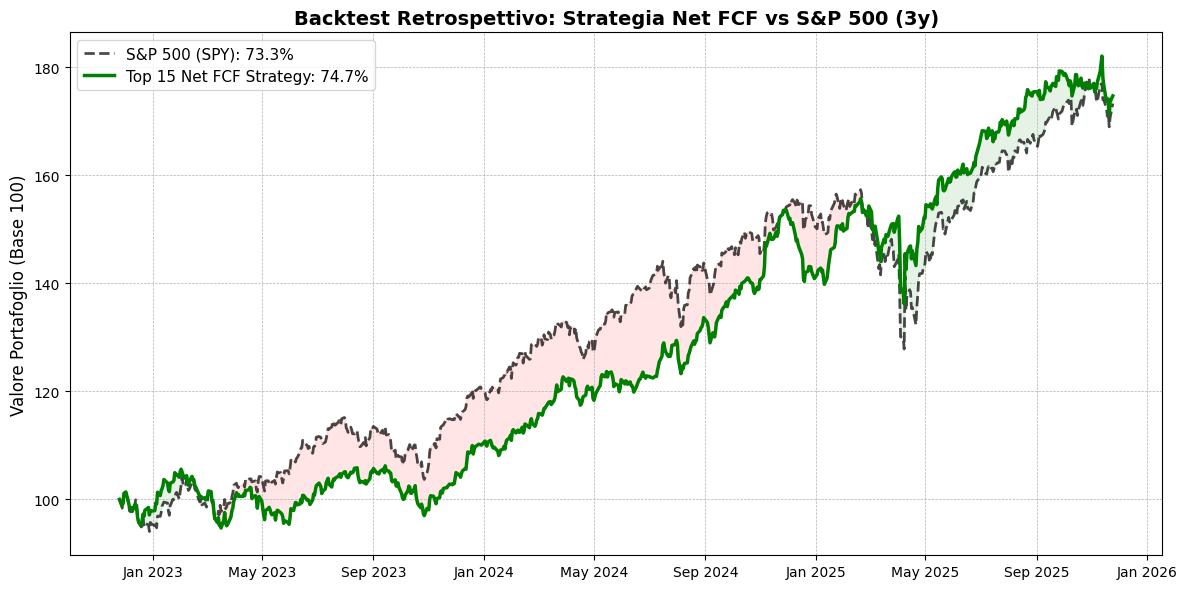

In [6]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# --- CONFIGURAZIONE ---
FILENAME = "Strategy_SectorNeutral_2025-11-24.xlsx"
BENCHMARK = "SPY"  # L'ETF dello S&P 500
PERIOD = "3y"      # '1y' = ultimo anno, 'ytd' = da inizio anno

def plot_performance():
    print("--- GENERAZIONE GRAFICO PERFORMANCE ---")
    
    # 1. Carica il Portafoglio generato
    try:
        df = pd.read_excel(FILENAME)
        # Prendiamo le Top 15 azioni della strategia
        top_stocks = df.head(15)['Ticker'].tolist()
        print(f"Portafoglio Strategia: {top_stocks}")
    except FileNotFoundError:
        print(f"Errore: File {FILENAME} non trovato. Esegui prima lo script precedente.")
        return

    # 2. Scarica i dati storici (Prezzi di Chiusura)
    print("Scaricamento dati storici prezzi...")
    tickers_to_download = top_stocks + [BENCHMARK]
    
    # yfinance scarica tutto insieme
    data = yf.download(tickers_to_download, period=PERIOD, auto_adjust=True, progress=False)['Close']
    
    if data.empty:
        print("Errore nel download dei prezzi.")
        return

    # 3. Calcola i Rendimenti
    # Rimuoviamo righe vuote se ci sono
    data.dropna(inplace=True)
    
    # Normalizzazione: Facciamo partire tutto da 100 (Base 100)
    # Formula: (Prezzo Giorno X / Prezzo Giorno 0) * 100
    normalized_data = (data / data.iloc[0]) * 100
    
    # 4. Costruisci l'indice del Portafoglio (Equal Weight)
    # Assumiamo di aver investito la stessa cifra in ognuna delle 15 azioni
    # La performance del portafoglio è la media delle performance delle singole azioni
    strategy_curve = normalized_data[top_stocks].mean(axis=1)
    benchmark_curve = normalized_data[BENCHMARK]
    
    # Calcolo Rendimento Totale Finale
    strat_return = strategy_curve.iloc[-1] - 100
    bench_return = benchmark_curve.iloc[-1] - 100
    alpha = strat_return - bench_return

    print(f"\n--- RISULTATI ({PERIOD}) ---")
    print(f"Rendimento Strategia (Top 15): {strat_return:.2f}%")
    print(f"Rendimento S&P 500 (SPY):      {bench_return:.2f}%")
    print(f"ALPHA (Sovraperformance):      {alpha:+.2f}%")

    # 5. PLOTTING (Grafico Professionale)
    plt.figure(figsize=(12, 6))
    
    # Plot Benchmark (Area grigia o linea nera)
    plt.plot(benchmark_curve.index, benchmark_curve, label=f'S&P 500 (SPY): {bench_return:.1f}%', 
             color='black', linewidth=2, alpha=0.7, linestyle='--')
    
    # Plot Strategia (Linea Verde Spessa)
    plt.plot(strategy_curve.index, strategy_curve, label=f'Top 15 Net FCF Strategy: {strat_return:.1f}%', 
             color='#008000', linewidth=2.5)
    
    # Fill between per evidenziare il guadagno/perdita
    plt.fill_between(strategy_curve.index, strategy_curve, benchmark_curve, 
                     where=(strategy_curve >= benchmark_curve), color='green', alpha=0.1, interpolate=True)
    plt.fill_between(strategy_curve.index, strategy_curve, benchmark_curve, 
                     where=(strategy_curve < benchmark_curve), color='red', alpha=0.1, interpolate=True)

    # Formattazione
    plt.title(f'Backtest Retrospettivo: Strategia Net FCF vs S&P 500 ({PERIOD})', fontsize=14, fontweight='bold')
    plt.ylabel('Valore Portafoglio (Base 100)', fontsize=12)
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.legend(loc='best', fontsize=11)
    
    # Formatta asse X per date leggibili
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    plot_performance()

--- GENERAZIONE GRAFICO PERFORMANCE ---
Portafoglio Strategia: ['NEM', 'SHW', 'T', 'VZ', 'BKNG', 'LOW', 'MO', 'PM', 'COP', 'XOM', 'COF', 'IBKR', 'BMY', 'MCK', 'CAT']
Scaricamento dati storici prezzi...

--- RISULTATI (2y) ---
Rendimento Strategia (Top 15): 68.17%
Rendimento S&P 500 (SPY):      50.82%
ALPHA (Sovraperformance):      +17.35%


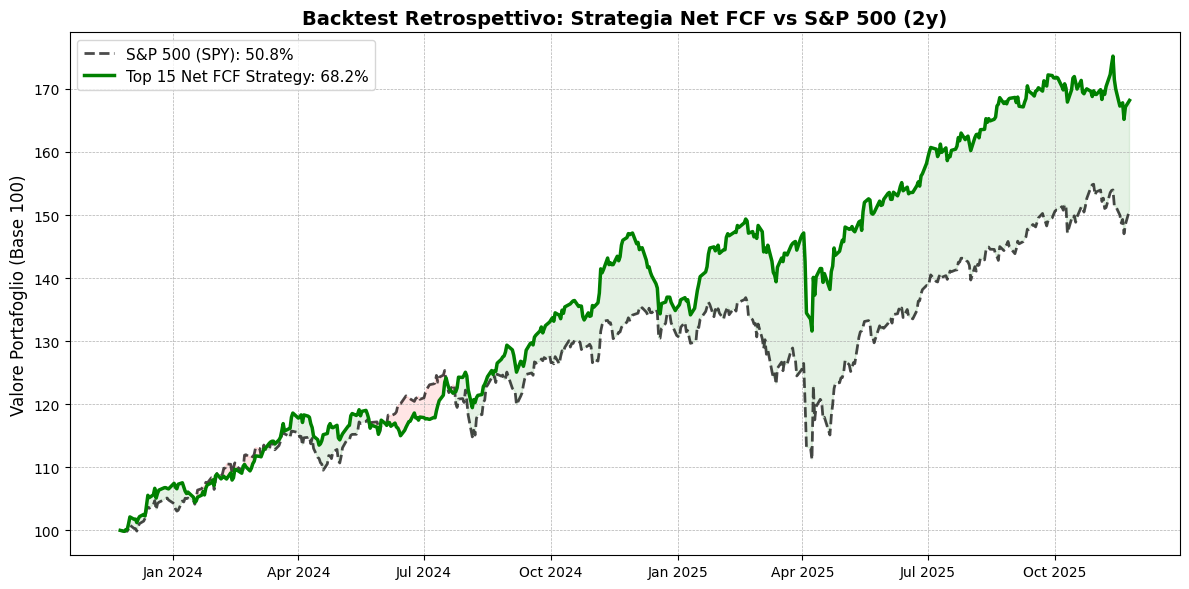

In [7]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# --- CONFIGURAZIONE ---
FILENAME = "Strategy_SectorNeutral_2025-11-24.xlsx"
BENCHMARK = "SPY"  # L'ETF dello S&P 500
PERIOD = "2y"      # '1y' = ultimo anno, 'ytd' = da inizio anno

def plot_performance():
    print("--- GENERAZIONE GRAFICO PERFORMANCE ---")
    
    # 1. Carica il Portafoglio generato
    try:
        df = pd.read_excel(FILENAME)
        # Prendiamo le Top 15 azioni della strategia
        top_stocks = df.head(15)['Ticker'].tolist()
        print(f"Portafoglio Strategia: {top_stocks}")
    except FileNotFoundError:
        print(f"Errore: File {FILENAME} non trovato. Esegui prima lo script precedente.")
        return

    # 2. Scarica i dati storici (Prezzi di Chiusura)
    print("Scaricamento dati storici prezzi...")
    tickers_to_download = top_stocks + [BENCHMARK]
    
    # yfinance scarica tutto insieme
    data = yf.download(tickers_to_download, period=PERIOD, auto_adjust=True, progress=False)['Close']
    
    if data.empty:
        print("Errore nel download dei prezzi.")
        return

    # 3. Calcola i Rendimenti
    # Rimuoviamo righe vuote se ci sono
    data.dropna(inplace=True)
    
    # Normalizzazione: Facciamo partire tutto da 100 (Base 100)
    # Formula: (Prezzo Giorno X / Prezzo Giorno 0) * 100
    normalized_data = (data / data.iloc[0]) * 100
    
    # 4. Costruisci l'indice del Portafoglio (Equal Weight)
    # Assumiamo di aver investito la stessa cifra in ognuna delle 15 azioni
    # La performance del portafoglio è la media delle performance delle singole azioni
    strategy_curve = normalized_data[top_stocks].mean(axis=1)
    benchmark_curve = normalized_data[BENCHMARK]
    
    # Calcolo Rendimento Totale Finale
    strat_return = strategy_curve.iloc[-1] - 100
    bench_return = benchmark_curve.iloc[-1] - 100
    alpha = strat_return - bench_return

    print(f"\n--- RISULTATI ({PERIOD}) ---")
    print(f"Rendimento Strategia (Top 15): {strat_return:.2f}%")
    print(f"Rendimento S&P 500 (SPY):      {bench_return:.2f}%")
    print(f"ALPHA (Sovraperformance):      {alpha:+.2f}%")

    # 5. PLOTTING (Grafico Professionale)
    plt.figure(figsize=(12, 6))
    
    # Plot Benchmark (Area grigia o linea nera)
    plt.plot(benchmark_curve.index, benchmark_curve, label=f'S&P 500 (SPY): {bench_return:.1f}%', 
             color='black', linewidth=2, alpha=0.7, linestyle='--')
    
    # Plot Strategia (Linea Verde Spessa)
    plt.plot(strategy_curve.index, strategy_curve, label=f'Top 15 Net FCF Strategy: {strat_return:.1f}%', 
             color='#008000', linewidth=2.5)
    
    # Fill between per evidenziare il guadagno/perdita
    plt.fill_between(strategy_curve.index, strategy_curve, benchmark_curve, 
                     where=(strategy_curve >= benchmark_curve), color='green', alpha=0.1, interpolate=True)
    plt.fill_between(strategy_curve.index, strategy_curve, benchmark_curve, 
                     where=(strategy_curve < benchmark_curve), color='red', alpha=0.1, interpolate=True)

    # Formattazione
    plt.title(f'Backtest Retrospettivo: Strategia Net FCF vs S&P 500 ({PERIOD})', fontsize=14, fontweight='bold')
    plt.ylabel('Valore Portafoglio (Base 100)', fontsize=12)
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.legend(loc='best', fontsize=11)
    
    # Formatta asse X per date leggibili
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    plot_performance()

--- GENERAZIONE GRAFICO PERFORMANCE ---
Portafoglio Strategia: ['NEM', 'SHW', 'T', 'VZ', 'BKNG', 'LOW', 'MO', 'PM', 'COP', 'XOM', 'COF', 'IBKR', 'BMY', 'MCK', 'CAT']
Scaricamento dati storici prezzi...

--- RISULTATI (1y) ---
Rendimento Strategia (Top 15): 14.22%
Rendimento S&P 500 (SPY):      13.39%
ALPHA (Sovraperformance):      +0.83%


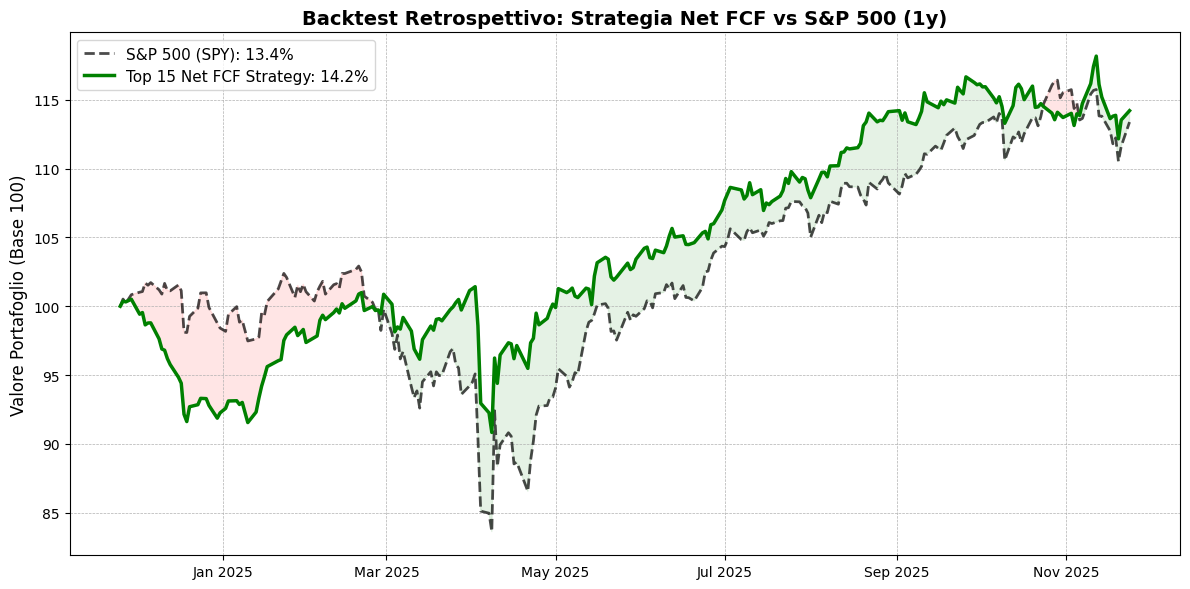

In [8]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# --- CONFIGURAZIONE ---
FILENAME = "Strategy_SectorNeutral_2025-11-24.xlsx"
BENCHMARK = "SPY"  # L'ETF dello S&P 500
PERIOD = "1y"      # '1y' = ultimo anno, 'ytd' = da inizio anno

def plot_performance():
    print("--- GENERAZIONE GRAFICO PERFORMANCE ---")
    
    # 1. Carica il Portafoglio generato
    try:
        df = pd.read_excel(FILENAME)
        # Prendiamo le Top 15 azioni della strategia
        top_stocks = df.head(15)['Ticker'].tolist()
        print(f"Portafoglio Strategia: {top_stocks}")
    except FileNotFoundError:
        print(f"Errore: File {FILENAME} non trovato. Esegui prima lo script precedente.")
        return

    # 2. Scarica i dati storici (Prezzi di Chiusura)
    print("Scaricamento dati storici prezzi...")
    tickers_to_download = top_stocks + [BENCHMARK]
    
    # yfinance scarica tutto insieme
    data = yf.download(tickers_to_download, period=PERIOD, auto_adjust=True, progress=False)['Close']
    
    if data.empty:
        print("Errore nel download dei prezzi.")
        return

    # 3. Calcola i Rendimenti
    # Rimuoviamo righe vuote se ci sono
    data.dropna(inplace=True)
    
    # Normalizzazione: Facciamo partire tutto da 100 (Base 100)
    # Formula: (Prezzo Giorno X / Prezzo Giorno 0) * 100
    normalized_data = (data / data.iloc[0]) * 100
    
    # 4. Costruisci l'indice del Portafoglio (Equal Weight)
    # Assumiamo di aver investito la stessa cifra in ognuna delle 15 azioni
    # La performance del portafoglio è la media delle performance delle singole azioni
    strategy_curve = normalized_data[top_stocks].mean(axis=1)
    benchmark_curve = normalized_data[BENCHMARK]
    
    # Calcolo Rendimento Totale Finale
    strat_return = strategy_curve.iloc[-1] - 100
    bench_return = benchmark_curve.iloc[-1] - 100
    alpha = strat_return - bench_return

    print(f"\n--- RISULTATI ({PERIOD}) ---")
    print(f"Rendimento Strategia (Top 15): {strat_return:.2f}%")
    print(f"Rendimento S&P 500 (SPY):      {bench_return:.2f}%")
    print(f"ALPHA (Sovraperformance):      {alpha:+.2f}%")

    # 5. PLOTTING (Grafico Professionale)
    plt.figure(figsize=(12, 6))
    
    # Plot Benchmark (Area grigia o linea nera)
    plt.plot(benchmark_curve.index, benchmark_curve, label=f'S&P 500 (SPY): {bench_return:.1f}%', 
             color='black', linewidth=2, alpha=0.7, linestyle='--')
    
    # Plot Strategia (Linea Verde Spessa)
    plt.plot(strategy_curve.index, strategy_curve, label=f'Top 15 Net FCF Strategy: {strat_return:.1f}%', 
             color='#008000', linewidth=2.5)
    
    # Fill between per evidenziare il guadagno/perdita
    plt.fill_between(strategy_curve.index, strategy_curve, benchmark_curve, 
                     where=(strategy_curve >= benchmark_curve), color='green', alpha=0.1, interpolate=True)
    plt.fill_between(strategy_curve.index, strategy_curve, benchmark_curve, 
                     where=(strategy_curve < benchmark_curve), color='red', alpha=0.1, interpolate=True)

    # Formattazione
    plt.title(f'Backtest Retrospettivo: Strategia Net FCF vs S&P 500 ({PERIOD})', fontsize=14, fontweight='bold')
    plt.ylabel('Valore Portafoglio (Base 100)', fontsize=12)
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.legend(loc='best', fontsize=11)
    
    # Formatta asse X per date leggibili
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    plot_performance()

--- GENERAZIONE GRAFICO PERFORMANCE ---
Portafoglio Strategia: ['NEM', 'SHW', 'T', 'VZ', 'BKNG', 'LOW', 'MO', 'PM', 'COP', 'XOM', 'COF', 'IBKR', 'BMY', 'MCK', 'CAT']
Scaricamento dati storici prezzi...

--- RISULTATI (4y) ---
Rendimento Strategia (Top 15): 95.87%
Rendimento S&P 500 (SPY):      54.12%
ALPHA (Sovraperformance):      +41.75%


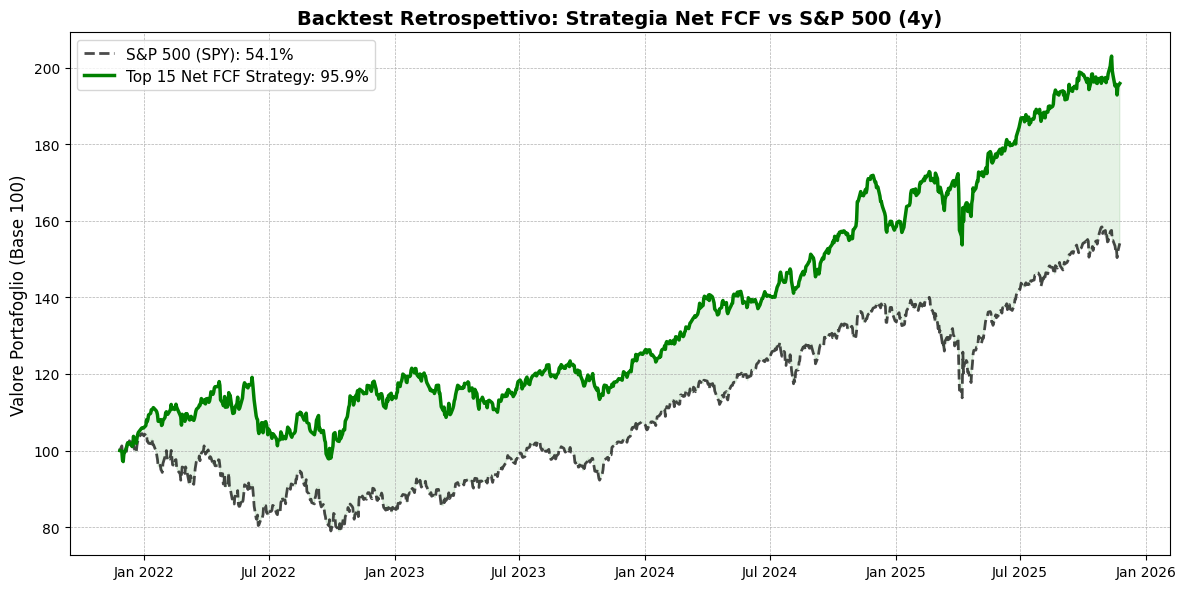

In [11]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# --- CONFIGURAZIONE ---
FILENAME = "Strategy_SectorNeutral_2025-11-24.xlsx"
BENCHMARK = "SPY"  # L'ETF dello S&P 500
PERIOD = "4y"      # '1y' = ultimo anno, 'ytd' = da inizio anno

def plot_performance():
    print("--- GENERAZIONE GRAFICO PERFORMANCE ---")
    
    # 1. Carica il Portafoglio generato
    try:
        df = pd.read_excel(FILENAME)
        # Prendiamo le Top 15 azioni della strategia
        top_stocks = df.head(15)['Ticker'].tolist()
        print(f"Portafoglio Strategia: {top_stocks}")
    except FileNotFoundError:
        print(f"Errore: File {FILENAME} non trovato. Esegui prima lo script precedente.")
        return

    # 2. Scarica i dati storici (Prezzi di Chiusura)
    print("Scaricamento dati storici prezzi...")
    tickers_to_download = top_stocks + [BENCHMARK]
    
    # yfinance scarica tutto insieme
    data = yf.download(tickers_to_download, period=PERIOD, auto_adjust=True, progress=False)['Close']
    
    if data.empty:
        print("Errore nel download dei prezzi.")
        return

    # 3. Calcola i Rendimenti
    # Rimuoviamo righe vuote se ci sono
    data.dropna(inplace=True)
    
    # Normalizzazione: Facciamo partire tutto da 100 (Base 100)
    # Formula: (Prezzo Giorno X / Prezzo Giorno 0) * 100
    normalized_data = (data / data.iloc[0]) * 100
    
    # 4. Costruisci l'indice del Portafoglio (Equal Weight)
    # Assumiamo di aver investito la stessa cifra in ognuna delle 15 azioni
    # La performance del portafoglio è la media delle performance delle singole azioni
    strategy_curve = normalized_data[top_stocks].mean(axis=1)
    benchmark_curve = normalized_data[BENCHMARK]
    
    # Calcolo Rendimento Totale Finale
    strat_return = strategy_curve.iloc[-1] - 100
    bench_return = benchmark_curve.iloc[-1] - 100
    alpha = strat_return - bench_return

    print(f"\n--- RISULTATI ({PERIOD}) ---")
    print(f"Rendimento Strategia (Top 15): {strat_return:.2f}%")
    print(f"Rendimento S&P 500 (SPY):      {bench_return:.2f}%")
    print(f"ALPHA (Sovraperformance):      {alpha:+.2f}%")

    # 5. PLOTTING (Grafico Professionale)
    plt.figure(figsize=(12, 6))
    
    # Plot Benchmark (Area grigia o linea nera)
    plt.plot(benchmark_curve.index, benchmark_curve, label=f'S&P 500 (SPY): {bench_return:.1f}%', 
             color='black', linewidth=2, alpha=0.7, linestyle='--')
    
    # Plot Strategia (Linea Verde Spessa)
    plt.plot(strategy_curve.index, strategy_curve, label=f'Top 15 Net FCF Strategy: {strat_return:.1f}%', 
             color='#008000', linewidth=2.5)
    
    # Fill between per evidenziare il guadagno/perdita
    plt.fill_between(strategy_curve.index, strategy_curve, benchmark_curve, 
                     where=(strategy_curve >= benchmark_curve), color='green', alpha=0.1, interpolate=True)
    plt.fill_between(strategy_curve.index, strategy_curve, benchmark_curve, 
                     where=(strategy_curve < benchmark_curve), color='red', alpha=0.1, interpolate=True)

    # Formattazione
    plt.title(f'Backtest Retrospettivo: Strategia Net FCF vs S&P 500 ({PERIOD})', fontsize=14, fontweight='bold')
    plt.ylabel('Valore Portafoglio (Base 100)', fontsize=12)
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.legend(loc='best', fontsize=11)
    
    # Formatta asse X per date leggibili
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    plot_performance()

In [10]:
import pandas as pd
import numpy as np
import yfinance as yf
import time
from io import StringIO
from datetime import datetime, timedelta
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.chrome.options import Options

# --- CONFIGURAZIONE UTENTE ---
BACKTEST_START_DATE = "2023-01-01"  # Data inizio simulazione (2 anni fa circa)
TOP_N_CAP_HISTORICAL = 150          # Universo (Top 150 dell'epoca)
STOCKS_PER_SECTOR = 2               # Diversificazione (2 per settore)
MIN_TREND_SCORE = 0.95              # Filtro Trend (SMA 200)

# --- 1. TIME MACHINE ROBUSTA (Fix 'Symbol' Error) ---
def get_universe_at_date(target_date_str):
    print(f"⏳ [Time Machine] Ricostruzione S&P 500 al {target_date_str}...")
    target_date = pd.to_datetime(target_date_str)
    
    # Setup Selenium
    chrome_options = Options()
    chrome_options.add_argument("--headless") 
    chrome_options.add_argument("--no-sandbox")
    chrome_options.add_argument("--disable-dev-shm-usage")
    service = Service(ChromeDriverManager().install())
    driver = webdriver.Chrome(service=service, options=chrome_options)
    
    try:
        driver.get("https://en.wikipedia.org/wiki/List_of_S%26P_500_companies")
        # Attesa tattica per rendering JS
        time.sleep(3)
        
        # FIX: Parsing intelligente delle tabelle
        tables = pd.read_html(StringIO(driver.page_source))
        print(f"   Trovate {len(tables)} tabelle totali nella pagina.")
        
        current_df = None
        changes_df = None
        
        # CERCHIAMO LE TABELLE GIUSTE
        for i, df in enumerate(tables):
            # 1. Cerchiamo la lista componenti (deve avere 'Symbol' e > 400 righe)
            if 'Symbol' in df.columns and len(df) > 400:
                current_df = df
                print(f"   ✅ Tabella Componenti trovata (indice {i})")
            
            # 2. Cerchiamo la lista modifiche (deve avere 'Date' e 'Added'/'Removed')
            # Nota: Wikipedia usa MultiIndex per questa tabella (Added -> Ticker)
            # Controlliamo se nelle colonne (anche appiattite) c'è 'Added'
            cols_str = str(df.columns)
            if 'Date' in cols_str and ('Added' in cols_str or 'Removed' in cols_str):
                changes_df = df
                print(f"   ✅ Tabella Modifiche trovata (indice {i})")
        
        if current_df is None:
            raise ValueError("Impossibile trovare la tabella dei componenti (Manca colonna 'Symbol').")
        
        # --- ELABORAZIONE ---
        # Lista di base (Oggi)
        tickers = set(current_df['Symbol'].replace('\.', '-', regex=True).tolist())
        print(f"   Componenti Oggi: {len(tickers)}")
        
        if changes_df is not None:
            # Pulizia Tabella Modifiche (Gestione MultiIndex o Flat)
            try:
                # Se è MultiIndex, appiattiamo o accediamo ai livelli
                if isinstance(changes_df.columns, pd.MultiIndex):
                    changes_df.columns = ['_'.join(col).strip() for col in changes_df.columns.values]
                    # Cerchiamo le colonne giuste dopo il flattening (es. 'Added_Ticker')
                    date_col = next(c for c in changes_df.columns if 'Date' in c)
                    added_col = next((c for c in changes_df.columns if 'Added' in c and 'Ticker' in c), None)
                    removed_col = next((c for c in changes_df.columns if 'Removed' in c and 'Ticker' in c), None)
                else:
                    # Formato Semplice
                    date_col = 'Date'
                    added_col = 'Added' # Da verificare puntualmente
                    removed_col = 'Removed'

                # Parsing Date
                changes_df[date_col] = pd.to_datetime(changes_df[date_col], errors='coerce')
                
                # Filtra modifiche avvenute DOPO la data target (da annullare)
                mask = changes_df[date_col] > target_date
                relevant_changes = changes_df[mask].sort_values(by=date_col, ascending=False)
                
                print(f"   Modifiche da riavvolgere: {len(relevant_changes)}")

                # Reverse Engineering
                for _, row in relevant_changes.iterrows():
                    added = row[added_col] if added_col and pd.notna(row[added_col]) else None
                    removed = row[removed_col] if removed_col and pd.notna(row[removed_col]) else None
                    
                    # Se aggiunto DOPO la data target -> RIMUOVI (non c'era)
                    if added:
                        added = str(added).replace('.', '-')
                        if added in tickers: tickers.remove(added)
                    
                    # Se rimosso DOPO la data target -> RIAGGIUNGI (c'era ancora)
                    if removed:
                        removed = str(removed).replace('.', '-')
                        tickers.add(removed)
            except Exception as e:
                print(f"⚠️ Warning elaborazione modifiche: {e}. Uso lista attuale.")
        
        reconstructed = list(tickers)
        print(f"✅ Universo Ricostruito: {len(reconstructed)} titoli.")
        return reconstructed
    
    except Exception as e:
        print(f"❌ Errore Critico Time Machine: {e}")
        return []
    finally:
        driver.quit()

# --- 2. DATA ENGINE: Dati "Point-in-Time" ---
def get_historical_metrics(ticker, ref_date_str):
    ref_date = pd.to_datetime(ref_date_str)
    stock = yf.Ticker(ticker)
    
    try:
        # A. PREZZO STORICO
        # Cerchiamo dati attorno alla data target
        hist = stock.history(start=ref_date - timedelta(days=10), end=ref_date + timedelta(days=10))
        
        if hist.empty:
            # Se non ci sono dati attorno a quella data, è un titolo morto/delistato
            return "DEAD"
        
        # Trova la data più vicina disponibile
        idx = hist.index.get_indexer([ref_date], method='nearest')[0]
        price_at_date = hist.iloc[idx]['Close']
        
        # Trend (SMA 200 all'epoca)
        start_trend = ref_date - timedelta(days=300)
        hist_long = stock.history(start=start_trend, end=ref_date)
        if len(hist_long) < 100: 
             return None # Troppo giovane
        
        sma_200 = hist_long['Close'].mean()
        trend_ratio = price_at_date / sma_200
        
        # B. MARKET CAP STORICO
        # Stima grezza: Prezzo * Shares attuali (non perfetto ma funzionale free)
        try:
            shares = stock.fast_info.shares
            if not shares: shares = stock.info.get('sharesOutstanding', 0)
        except:
            shares = 0
            
        if shares == 0: return None
        historical_mkt_cap = price_at_date * shares

        # C. FREE CASH FLOW (Dal bilancio più recente rispetto alla data)
        cf = stock.cashflow
        if cf.empty: return None
        
        # Filtra colonne (date) anteriori alla ref_date
        valid_cols = [c for c in cf.columns if pd.to_datetime(c) < ref_date]
        if not valid_cols: return None
        
        report_date = max(valid_cols) # Ultimo bilancio disponibile all'epoca
        
        def get_val(df, keys, col):
            for k in keys:
                if k in df.index: return df.loc[k][col]
            return 0

        ocf = get_val(cf, ['Total Cash From Operating Activities', 'Operating Cash Flow'], report_date)
        capex = get_val(cf, ['Capital Expenditures', 'Capital Expenditure'], report_date)
        dividends = get_val(cf, ['Cash Dividends Paid', 'Common Stock Dividend Paid'], report_date)

        if ocf == 0: return None
        
        fcf = ocf + capex
        net_fcf = fcf + dividends
        yield_pct = (net_fcf / historical_mkt_cap) * 100

        # D. ROI REALE (Survivorship Killer)
        # Prezzo oggi
        curr_hist = stock.history(period='5d')
        if curr_hist.empty:
            roi = -1.0 # PERSO TUTTO (Delisted dopo l'acquisto)
        else:
            curr_price = curr_hist['Close'].iloc[-1]
            roi = (curr_price - price_at_date) / price_at_date

        return {
            'Ticker': ticker,
            'Trend Score': trend_ratio,
            'Net FCF Yield (%)': yield_pct,
            'Market Cap (Est)': historical_mkt_cap,
            'Sector': stock.info.get('sector', 'Unknown'),
            'ROI': roi
        }

    except Exception:
        return "DEAD"

# --- 3. MAIN RUNNER ---
def run_robust_pipeline():
    print(f"🚀 AVVIO PIPELINE UNICA (Survivorship Bias Killer)")
    print(f"📅 Data Backtest: {BACKTEST_START_DATE}")
    
    # 1. Ricostruzione
    universe = get_universe_at_date(BACKTEST_START_DATE)
    if not universe: return

    print(f"\n🔬 Analisi Fondamentale Storica su {len(universe)} titoli...")
    candidates = []
    
    # LIMITIAMO A 50 PER TEST VELOCE (Togli [:50] per farlo tutto)
    for i, t in enumerate(universe[:100]): 
        print(f"[{i+1}] {t:<5}", end="\r")
        data = get_historical_metrics(t, BACKTEST_START_DATE)
        
        if data == "DEAD": continue
        if data and isinstance(data, dict):
            if data['Trend Score'] >= MIN_TREND_SCORE:
                candidates.append(data)
                
    # Creazione Portafoglio
    df = pd.DataFrame(candidates)
    if df.empty:
        print("Nessun candidato trovato.")
        return

    # Selezione Sector Neutral
    portfolio = []
    for sec in df['Sector'].unique():
        if sec == 'Unknown': continue
        sec_df = df[df['Sector'] == sec].sort_values(by='Net FCF Yield (%)', ascending=False)
        portfolio.append(sec_df.head(STOCKS_PER_SECTOR))
        
    final_port = pd.concat(portfolio)
    
    # Risultati
    print("\n\n📊 RISULTATI BACKTEST REALE")
    avg_roi = final_port['ROI'].mean()
    
    print("-" * 65)
    print(f"{'Ticker':<8} | {'Settore':<20} | {'Yield Storico':<10} | {'ROI'}")
    print("-" * 65)
    
    for _, row in final_port.iterrows():
        roi_txt = "💀 FALLITO" if row['ROI'] <= -0.99 else f"{row['ROI']*100:+.2f}%"
        print(f"{row['Ticker']:<8} | {row['Sector']:<20} | {row['Net FCF Yield (%)']:.1f}%      | {roi_txt}")
        
    print("-" * 65)
    print(f"RITORNO MEDIO STRATEGIA: {avg_roi*100:+.2f}%")

if __name__ == "__main__":
    run_robust_pipeline()

🚀 AVVIO PIPELINE UNICA (Survivorship Bias Killer)
📅 Data Backtest: 2023-01-01
⏳ [Time Machine] Ricostruzione S&P 500 al 2023-01-01...
   Trovate 3 tabelle totali nella pagina.
   ✅ Tabella Componenti trovata (indice 1)
   ✅ Tabella Modifiche trovata (indice 2)
   Componenti Oggi: 503
   Modifiche da riavvolgere: 52
✅ Universo Ricostruito: 503 titoli.

🔬 Analisi Fondamentale Storica su 503 titoli...


$FRC: possibly delisted; no timezone found


$PXD: possibly delisted; no timezone found


$SBNY: possibly delisted; no price data found  (1d 2022-12-22 00:00:00 -> 2023-01-11 00:00:00) (Yahoo error = "Data doesn't exist for startDate = 1671685200, endDate = 1673413200")


$JNPR: possibly delisted; no timezone found


Nessun candidato trovato.
